# Task 5: Interactive Business Dashboard in Streamlit

## Objective
Build an interactive Streamlit dashboard to analyze sales, profit, and segment-wise performance with filters for Region, Category, and Sub-Category.

## Dataset
Global Superstore Dataset

## 1. Data Loading

In [2]:
!wget -q "https://raw.githubusercontent.com/yannie28/Global-Superstore/master/Global_Superstore%28CSV%29.csv" -O superstore.csv
!head -c 300 superstore.csv

﻿Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,State,Country,Region,Market,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
40098,CA-2014-AB10015140-41954,11/11/2014,11/13/2014,First Class,

In [3]:
import pandas as pd
df = pd.read_csv("superstore.csv", encoding='latin1')
df.shape

(1000, 24)

In [4]:
df.head()

,ï»¿Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,40098,CA-2014-AB10015140-41954,11/11/2014,11/13/2014,First Class,AB-100151402,Aaron Bergman,Consumer,73120.0,Oklahoma City,...,TEC-PH-5816,Technology,Phones,Samsung Convoy 3,221.98,2,0.0,62.15,40.77,High
1,26341,IN-2014-JR162107-41675,2/5/2014,2/7/2014,Second Class,JR-162107,Justin Ritter,Corporate,NaN,Wollongong,...,FUR-CH-5379,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.40,9,0.1,-288.77,923.63,Critical
2,25330,IN-2014-CR127307-41929,10/17/2014,10/18/2014,First Class,CR-127307,Craig Reiter,Consumer,NaN,Brisbane,...,TEC-PH-5356,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.17,9,0.1,919.97,915.49,Medium
3,13524,ES-2014-KM1637548-41667,1/28/2014,1/30/2014,First Class,KM-1637548,Katherine Murray,Home Office,NaN,Berlin,...,TEC-PH-5267,Technology,Phones,"Motorola Smart Phone, Cordless",2892.51,5,0.1,-96.54,910.16,Medium
4,47221,SG-2014-RH9495111-41948,11/5/2014,11/6/2014,Same Day,RH-9495111,Rick Hansen,Consumer,NaN,Dakar,...,TEC-CO-6011,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.96,8,0.0,311.52,903.04,Critical


In [5]:
df.columns = df.columns.str.replace('ï»¿', '', regex=False)
print(df.shape)
df.columns.tolist()

(1000, 24)


['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Postal Code',
 'City',
 'State',
 'Country',
 'Region',
 'Market',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit',
 'Shipping Cost',
 'Order Priority']

## 2. Data Cleaning & EDA

In [6]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Postal Code,806
City,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          1000 non-null   int64  
 1   Order ID        1000 non-null   object 
 2   Order Date      1000 non-null   object 
 3   Ship Date       1000 non-null   object 
 4   Ship Mode       1000 non-null   object 
 5   Customer ID     1000 non-null   object 
 6   Customer Name   1000 non-null   object 
 7   Segment         1000 non-null   object 
 8   Postal Code     194 non-null    float64
 9   City            1000 non-null   object 
 10  State           1000 non-null   object 
 11  Country         1000 non-null   object 
 12  Region          1000 non-null   object 
 13  Market          1000 non-null   object 
 14  Product ID      1000 non-null   object 
 15  Category        1000 non-null   object 
 16  Sub-Category    1000 non-null   object 
 17  Product Name    1000 non-null   ob

In [8]:
df[['Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost']].describe()

,Sales,Quantity,Discount,Profit,Shipping Cost
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,1710.971470,5.55800,0.092840,288.920440,272.384897
std,1259.239238,2.71846,0.148666,574.504782,176.160716
min,1.910000,1.00000,0.000000,-3059.820000,1.070000
25%,826.907500,4.00000,0.000000,10.037500,209.827500
50%,1585.115000,5.00000,0.000000,190.685000,258.897500
75%,2477.812500,7.00000,0.150000,518.872500,351.070250
max,9892.740000,14.00000,0.800000,4946.370000,923.630000


In [9]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df.dtypes[['Order Date', 'Ship Date']]

,0
Order Date,datetime64[ns]
Ship Date,datetime64[ns]


### 2.1 Quick Overview of Key Metrics

In [10]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Orders: {total_orders}")

Total Sales: $1,710,971.47
Total Profit: $288,920.44
Total Orders: 867


### 2.2 Sales & Profit by Category

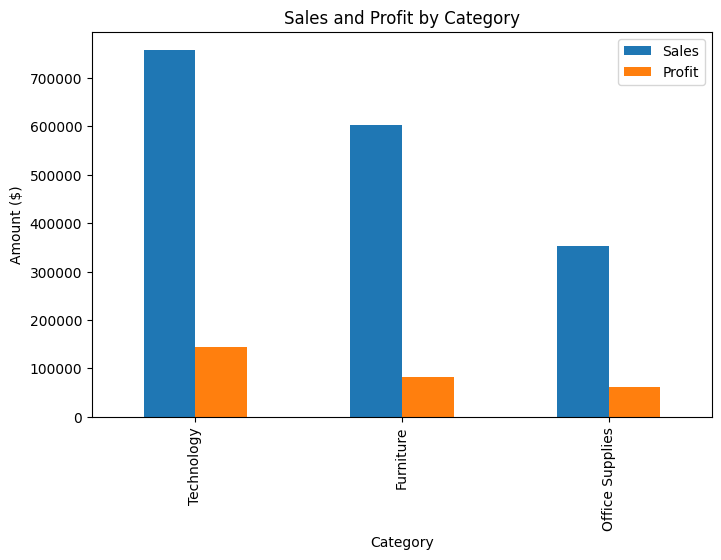

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

category_summary = df.groupby('Category')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)
category_summary.plot(kind='bar', figsize=(8, 5))
plt.title('Sales and Profit by Category')
plt.ylabel('Amount ($)')
plt.show()

### 2.3 Sales by Region

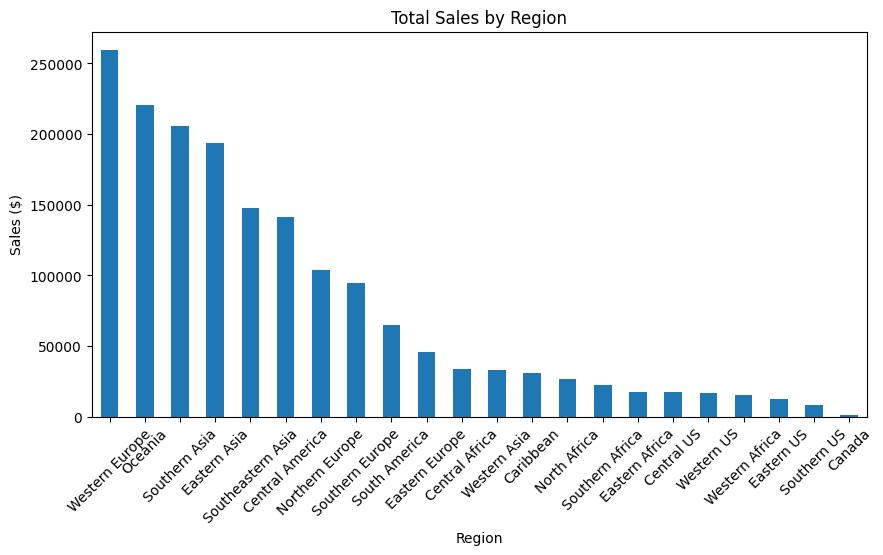

In [12]:
region_summary = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
region_summary.plot(kind='bar')
plt.title('Total Sales by Region')
plt.ylabel('Sales ($)')
plt.xticks(rotation=45)
plt.show()

## 3. Conclusion

### Key Findings:
- Technology category generates the highest sales among the three categories.
- Some orders result in significant losses (negative profit), particularly with high discount rates.
- Sales are distributed across multiple global regions, with notable variation in performance.

### Next Steps:
- Build an interactive Streamlit dashboard with filters for Region, Category, and Sub-Category
- Display KPIs (Total Sales, Profit, Top 5 Customers) dynamically based on filter selections

## 4. Saving Cleaned Data for Dashboard

In [13]:
df.to_csv('superstore_cleaned.csv', index=False)

from google.colab import files
files.download('superstore_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>